# Tugas 2 - Klasifikasi Diabetes dengan Naive Bayes dan Logistic Regression

| Nama | NRP |
|------|-----|
| Sandi Suryo Nugroho | 5054251020|

## Deskripsi Tugas
Pada tugas ini, kita akan menggunakan Pima Indians Diabetes Dataset. Dataset bisa diakses melalui link berikut:\
https://www.kaggle.com/datasets/jamaltariqcheema/pima-indians-diabetes-dataset

Tujuan utama dari tugas ini adalah membangun model Naive Bayes dan Logistic Regression untuk mengklasifikasikan apakah seorang pasien menderita diabetes atau tidak.

Langkah-langkah yang harus dilakukan antara lain:
1. Persiapan Dataset dan Eksplorasi Awal
   - Memuat dataset, melihat struktur data, dan distribusi label.
2. Preprocessing
   - Memproses data agar siap digunakan dalam membangun model.
3. Eksperimen Model
   - Bangun model Gaussian Naive Bayes dan Logistic Regression.
4. Evaluasi Model
   - Hitung metrik evaluasi dan visualisasikan hasilnya.
5. Analisis dan Kesimpulan
   - Bandingkan hasil kedua model dan berikan kesimpulan.

# 1. Persiapan Dataset dan Eksplorasi Awal

In [1]:
# Import library yang dibutuhkan (pandas, numpy, matplotlib, seaborn, sklearn, dll)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, roc_curve, auc)

sns.set_style("whitegrid")
RANDOM_STATE = 42


In [2]:
# Load dataset dan tampilkan informasi dasar: jumlah baris dan kolom, tipe data, statistik deskriptif, dan jumlah missing value.
df = pd.read_csv("diabetes.csv")

print(f"Jumlah baris dan kolom: {df.shape}")
print()
print("Tipe data tiap kolom:")
print(df.dtypes)
print()
print("Jumlah missing value (NaN) per kolom:")
print(df.isnull().sum())
print()
print("Statistik deskriptif:")
df.describe()


Jumlah baris dan kolom: (768, 9)

Tipe data tiap kolom:
Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

Jumlah missing value (NaN) per kolom:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Statistik deskriptif:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


Outcome
0    500
1    268
Name: count, dtype: int64
Proporsi kelas 1 (diabetes): 34.90%


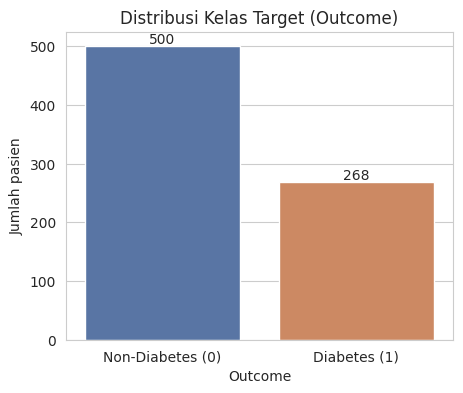

In [3]:
# Tampilkan distribusi kelas target (Outcome) dalam bentuk bar plot.
# Perhatikan apakah dataset ini imbalanced.
outcome_counts = df['Outcome'].value_counts().sort_index()
print(outcome_counts)
print(f"Proporsi kelas 1 (diabetes): {outcome_counts[1] / len(df):.2%}")

plt.figure(figsize=(5, 4))
sns.barplot(x=outcome_counts.index, y=outcome_counts.values, hue=outcome_counts.index,
            palette=["#4C72B0", "#DD8452"], legend=False)
plt.xticks([0, 1], ["Non-Diabetes (0)", "Diabetes (1)"])
plt.ylabel("Jumlah pasien")
plt.title("Distribusi Kelas Target (Outcome)")
for i, v in enumerate(outcome_counts.values):
    plt.text(i, v + 5, str(v), ha='center')
plt.show()


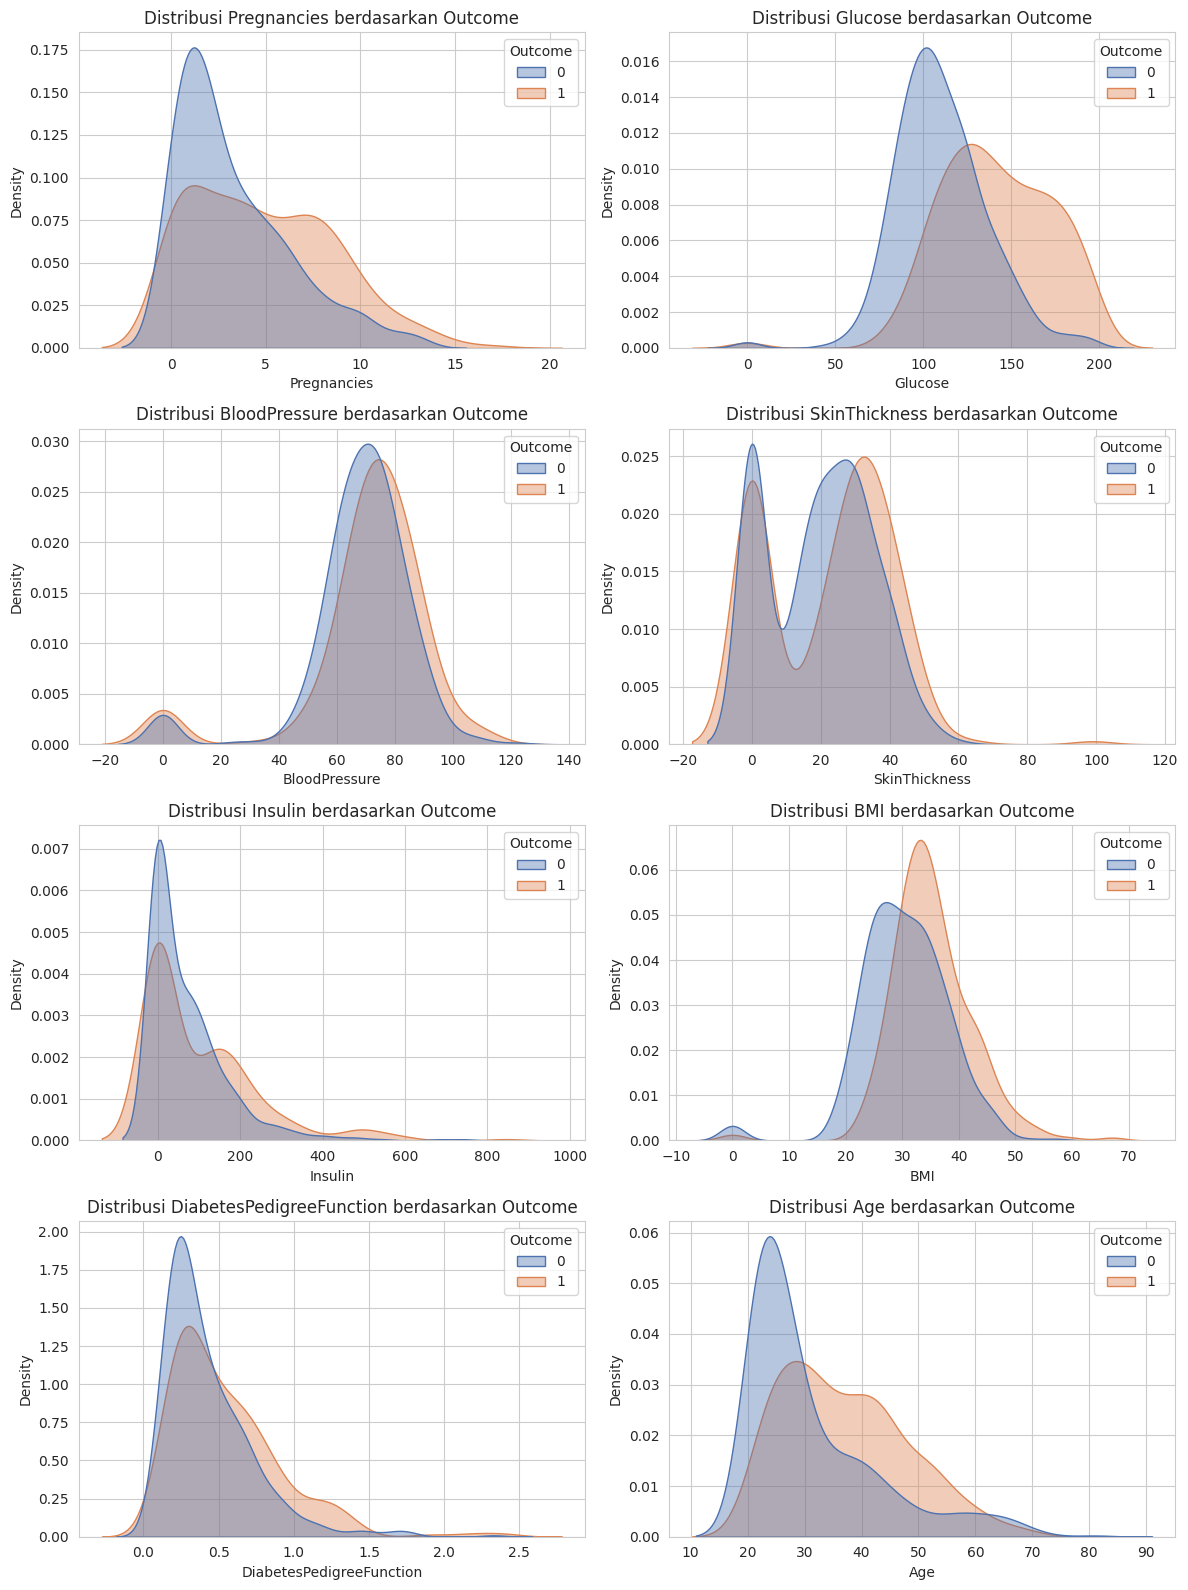

In [4]:
# Tampilkan distribusi setiap fitur menggunakan histogram atau KDE plot, dibedakan berdasarkan kelas Outcome.
features = [c for c in df.columns if c != 'Outcome']

fig, axes = plt.subplots(4, 2, figsize=(12, 16))
axes = axes.flatten()
for i, col in enumerate(features):
    sns.kdeplot(data=df, x=col, hue='Outcome', fill=True, common_norm=False,
                alpha=0.4, ax=axes[i], palette=["#4C72B0", "#DD8452"])
    axes[i].set_title(f"Distribusi {col} berdasarkan Outcome")
plt.tight_layout()
plt.show()


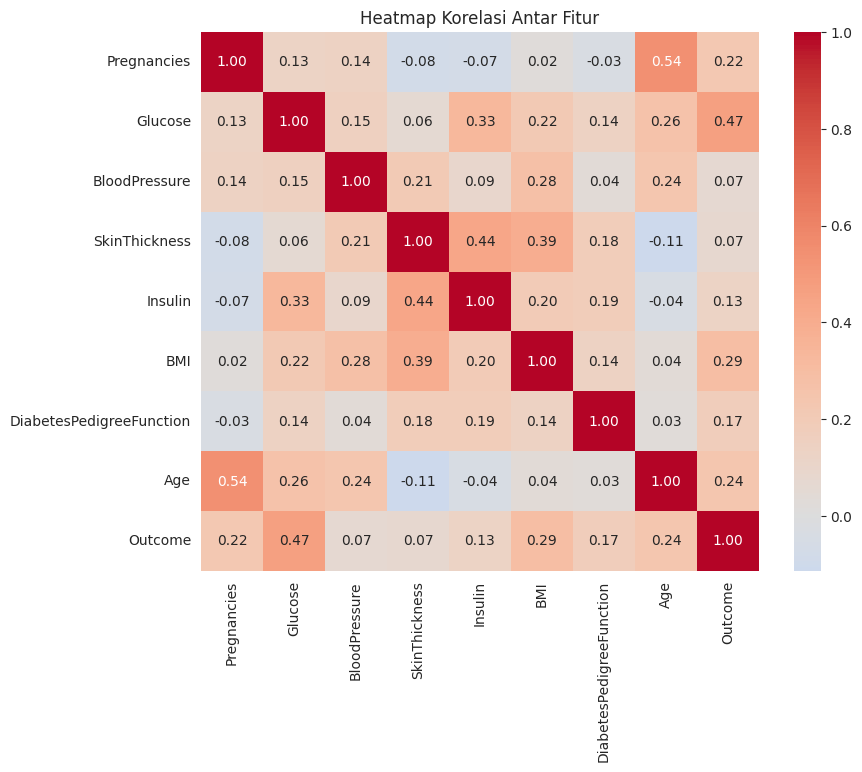

In [5]:
# Tampilkan heatmap korelasi antar fitur.
plt.figure(figsize=(9, 7))
corr = df.corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Heatmap Korelasi Antar Fitur")
plt.show()


## Lakukan Exploratory Data Analysis (EDA) tambahan yang diperlukan.

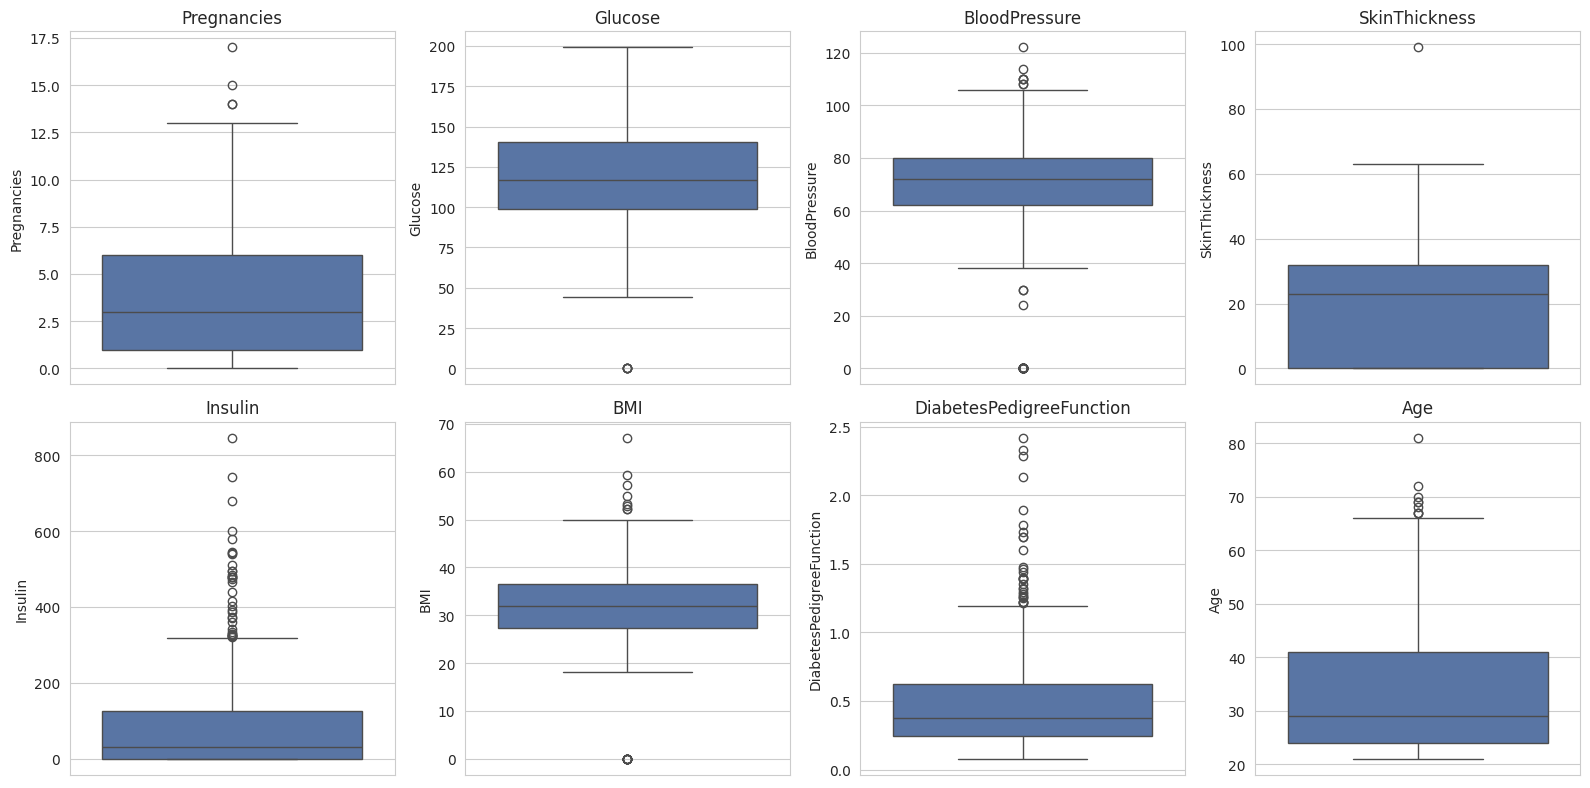

Insight EDA tambahan:
- Insulin dan SkinThickness punya banyak outlier & sebaran yang lebar.
- Glucose, BloodPressure, SkinThickness, Insulin, BMI punya nilai 0 yang
  secara medis tidak masuk akal (akan ditangani di tahap preprocessing).


In [ ]:
# EDA tambahan: boxplot tiap fitur untuk melihat sebaran & potensi outlier,
# serta cek proporsi nilai 0 yang mencurigakan secara medis pada beberapa kolom.
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()
for i, col in enumerate(features):
    sns.boxplot(y=df[col], ax=axes[i], color="#4C72B0")
    axes[i].set_title(col)
plt.tight_layout()
plt.show()


Insight EDA tambahan:
- Insulin dan SkinThickness punya banyak outlier & sebaran yang lebar.
- Glucose, BloodPressure, SkinThickness, Insulin, BMI punya nilai 0 yang
  secara medis tidak masuk akal (akan ditangani di tahap preprocessing).

# 2. Preprocessing

In [7]:
# Beberapa kolom seperti Glucose, BloodPressure, SkinThickness, Insulin, dan BMI memiliki nilai 0 yang secara medis tidak mungkin.
# Identifikasi kolom-kolom tersebut dan hitung jumlah nilai 0 pada masing-masing kolom.
cols_invalid_zero = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

zero_counts = (df[cols_invalid_zero] == 0).sum()
zero_pct = (zero_counts / len(df) * 100).round(2)
pd.DataFrame({'jumlah_nilai_0': zero_counts, 'persentase (%)': zero_pct})


,jumlah_nilai_0,persentase (%)
Glucose,5,0.65
BloodPressure,35,4.56
SkinThickness,227,29.56
Insulin,374,48.70
BMI,11,1.43


In [ ]:
# Tangani nilai 0 tersebut dengan strategi yang sesuai (misalnya imputasi dengan median atau mean).
# Pastikan strategi yang dipilih tidak memperkenalkan data leakage.

df_clean = df.copy()
df_clean[cols_invalid_zero] = df_clean[cols_invalid_zero].replace(0, np.nan)

print("Jumlah NaN setelah nilai 0 direlabel:")
print(df_clean[cols_invalid_zero].isnull().sum())


Jumlah NaN setelah nilai 0 direlabel:
Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64


In [ ]:
# Pisahkan fitur (X) dan target (y).
# Bagi data menjadi train set dan test set (misalnya 80:20).
# Gunakan stratify=y agar distribusi kelas tetap proporsional.
X = df_clean.drop(columns=['Outcome'])
y = df_clean['Outcome']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f"Ukuran X_train: {X_train.shape}, X_test: {X_test.shape}")
print("Proporsi kelas di y_train:")
print(y_train.value_counts(normalize=True))
print("Proporsi kelas di y_test:")
print(y_test.value_counts(normalize=True))

imputer = SimpleImputer(strategy='median')
X_train = pd.DataFrame(imputer.fit_transform(X_train), columns=X.columns, index=X_train.index)
X_test = pd.DataFrame(imputer.transform(X_test), columns=X.columns, index=X_test.index)


Ukuran X_train: (614, 8), X_test: (154, 8)
Proporsi kelas di y_train:
Outcome
0    0.651466
1    0.348534
Name: proportion, dtype: float64
Proporsi kelas di y_test:
Outcome
0    0.649351
1    0.350649
Name: proportion, dtype: float64


In [10]:
# Lakukan feature scaling menggunakan StandardScaler.
# Fit hanya pada train set, kemudian transform pada train set dan test set.
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X.columns, index=X_test.index)

X_train_scaled.describe().loc[['mean', 'std']]


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
mean,-6.943414e-17,-1.099374e-16,3.095606e-16,-3.471707e-17,-4.339634e-18,1.649061e-16,-1.099374e-16,-1.084908e-16
std,1.000815e+00,1.000815e+00,1.000815e+00,1.000815e+00,1.000815e+00,1.000815e+00,1.000815e+00,1.000815e+00


# 3. Eksperimen Model

## 3.1 Gaussian Naive Bayes

Gunakan GaussianNB karena semua fitur pada dataset ini bersifat numerik kontinu.

In [11]:
# Inisialisasi dan latih model Gaussian Naive Bayes menggunakan train set.
gnb = GaussianNB()
gnb.fit(X_train_scaled, y_train)


,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09


In [12]:
# Lakukan prediksi pada test set.
# Simpan hasil prediksi label dan probabilitas kelas 1 untuk keperluan evaluasi.
y_pred_nb = gnb.predict(X_test_scaled)
y_proba_nb = gnb.predict_proba(X_test_scaled)[:, 1]


## 3.2 Logistic Regression

In [13]:
# Inisialisasi dan latih model Logistic Regression menggunakan train set.
lr = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
lr.fit(X_train_scaled, y_train)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [14]:
# Lakukan prediksi pada test set.
# Simpan hasil prediksi label dan probabilitas kelas 1 untuk keperluan evaluasi.
y_pred_lr = lr.predict(X_test_scaled)
y_proba_lr = lr.predict_proba(X_test_scaled)[:, 1]


# 4. Evaluasi Model

In [15]:
# Tampilkan metrik evaluasi untuk setiap model: Accuracy, Precision, Recall, dan F1-Score.
def get_metrics(y_true, y_pred):
    return {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1-Score': f1_score(y_true, y_pred),
    }

results = pd.DataFrame({
    'Gaussian Naive Bayes': get_metrics(y_test, y_pred_nb),
    'Logistic Regression': get_metrics(y_test, y_pred_lr),
}).T

results.round(4)


,Accuracy,Precision,Recall,F1-Score
Gaussian Naive Bayes,0.7013,0.5667,0.6296,0.5965
Logistic Regression,0.7078,0.6000,0.5000,0.5455


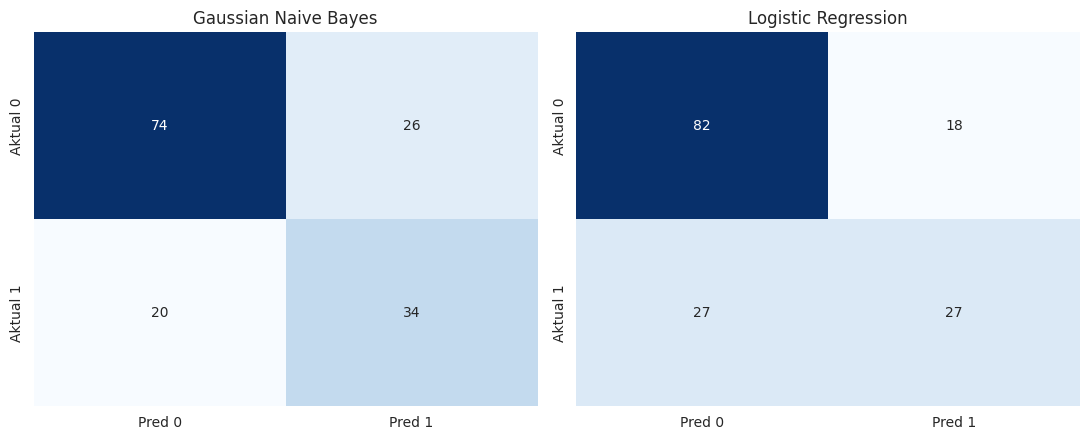

In [16]:
# Tampilkan Confusion Matrix setiap model dalam bentuk heatmap.
cm_nb = confusion_matrix(y_test, y_pred_nb)
cm_lr = confusion_matrix(y_test, y_pred_lr)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, cm, title in zip(axes, [cm_nb, cm_lr], ["Gaussian Naive Bayes", "Logistic Regression"]):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['Pred 0', 'Pred 1'], yticklabels=['Aktual 0', 'Aktual 1'], ax=ax)
    ax.set_title(title)
plt.tight_layout()
plt.show()


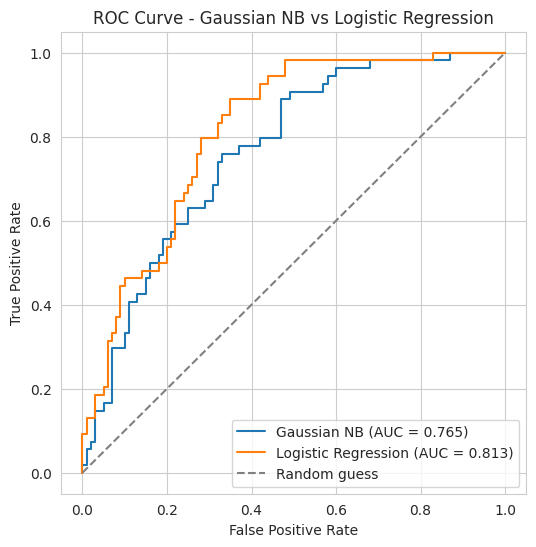

In [17]:
# Tampilkan ROC Curve kedua model dalam satu plot beserta nilai AUC masing-masing.
fpr_nb, tpr_nb, _ = roc_curve(y_test, y_proba_nb)
auc_nb = auc(fpr_nb, tpr_nb)

fpr_lr, tpr_lr, _ = roc_curve(y_test, y_proba_lr)
auc_lr = auc(fpr_lr, tpr_lr)

plt.figure(figsize=(6, 6))
plt.plot(fpr_nb, tpr_nb, label=f"Gaussian NB (AUC = {auc_nb:.3f})")
plt.plot(fpr_lr, tpr_lr, label=f"Logistic Regression (AUC = {auc_lr:.3f})")
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random guess')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Gaussian NB vs Logistic Regression")
plt.legend()
plt.show()


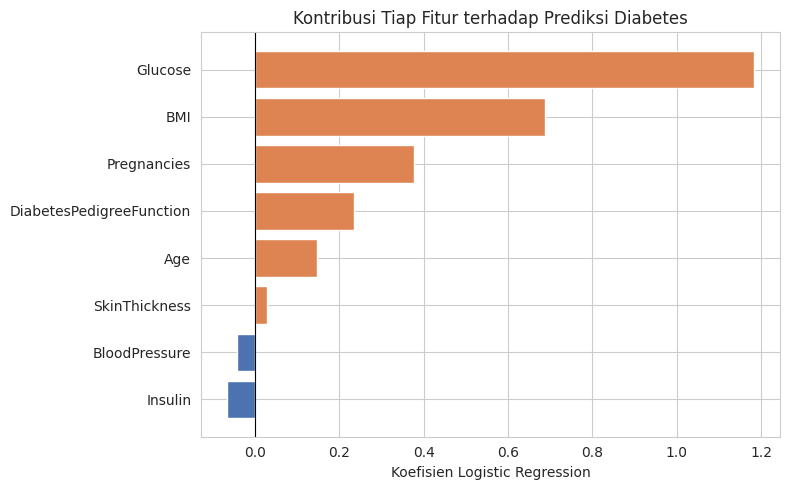

In [18]:
# Khusus Logistic Regression: tampilkan koefisien setiap fitur dalam bentuk bar chart horizontal.
# Koefisien positif menandakan fitur meningkatkan probabilitas diabetes, negatif sebaliknya.
coef_series = pd.Series(lr.coef_[0], index=X.columns).sort_values()

plt.figure(figsize=(8, 5))
colors = ['#DD8452' if c > 0 else '#4C72B0' for c in coef_series.values]
plt.barh(coef_series.index, coef_series.values, color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel("Koefisien Logistic Regression")
plt.title("Kontribusi Tiap Fitur terhadap Prediksi Diabetes")
plt.tight_layout()
plt.show()


# 5. Analisis

**Hasil metrik pada test set (20% data, 154 sampel):**

| Model | Accuracy | Precision | Recall | F1-Score | AUC |
|---|---|---|---|---|---|
| Gaussian Naive Bayes | 0.701 | 0.567 | 0.630 | 0.596 | 0.765 |
| Logistic Regression | 0.708 | 0.600 | 0.500 | 0.545 | 0.813 |

**Perbandingan:**

**Analisis:**
- Accuracy kedua model mirip (~70%), jadi kurang informatif untuk data yang agak imbalanced (65:35).

- **Gaussian NB**: Recall 0.63, F1 0.596 lebih baik menangkap pasien diabetes (false negative lebih sedikit).
- **Logistic Regression**: Precision 0.60, AUC 0.813 (vs NB 0.765) lebih baik membedakan kedua kelas secara keseluruhan.
- Gap ini masuk akal: NB mengasumsikan fitur saling independen, padahal beberapa fitur (Glucose–Insulin, Age–Pregnancies) berkorelasi, jadi probabilitasnya kurang presisi.
- Glucose dan BMI adalah prediktor terkuat (koefisien LR terbesar), sesuai intuisi medis dan pola di EDA.


# 6. Kesimpulan dan Saran

**Kesimpulan:**

- Tidak ada model yang unggul mutlak. NB lebih baik di Recall/F1, LR lebih baik di Precision/AUC.

- Untuk deteksi penyakit, Recall biasanya lebih penting. NB sedikit lebih "aman", tapi LR lebih robust secara keseluruhan (AUC).
- Saran lanjutan: tuning threshold LR, tangani imbalance (class_weight/SMOTE), coba model lain (Random Forest), pakai cross-validation.

**Saran untuk eksperimen selanjutnya:**
- Tuning threshold pada Logistic Regression untuk naikkan Recall.

- Tangani imbalance kelas (class_weight='balanced' atau SMOTE).

- Coba cross-validation agar evaluasi lebih stabil.